c:\Users\fxfar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


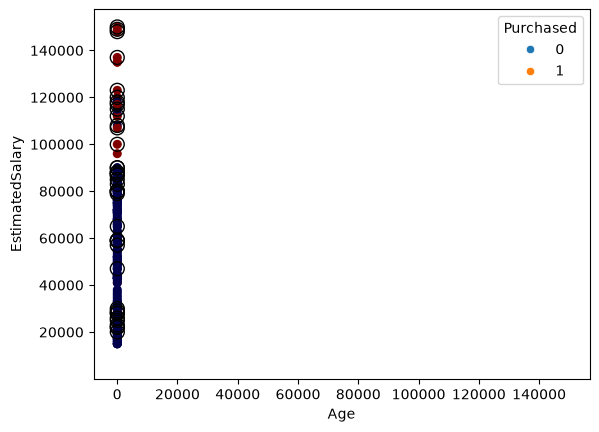

In [10]:
import pandas as jo

i = jo.read_csv('social_network_ads.csv')

a = jo.read_csv('social_network_ads.csv', usecols = [ 'Age' ,'EstimatedSalary', 'Purchased' ])
a = a.iloc[ 0:200 ]
a.head(5)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot( x = 'Age', y = 'EstimatedSalary', hue = 'Purchased', data = a)

from sklearn.svm import SVC
X = a.drop('Purchased',axis = 1)
y =a['Purchased']

model = SVC(kernel = 'linear', C = 20)

model.fit(X,y)

def plot_svm_boundary(model, X, y) :

        X = X.values
        y = y.values

        # Scatter plot
        plt.scatter(X[:, 0], X[:, 1], c = y, s = 30, cmap = 'seismic')

        # plot the decision function
        ax = plt.gca()
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()

        # create grid to evaluate model
        xx = np.linspace(xlim[0], xlim[1], 30)
        yy = np.linspace(ylim[0], ylim[1], 30)  
        YY, XX = np.meshgrid(xx, yy)
        xy = np.vstack([XX.ravel(), YY.ravel()]).T
        z = model.decision_function(xy).reshape(XX.shape)

        # plot decision boundary and margins
        ax.contour(XX, YY, z, colors = 'k', levels = [-1, 0, 1], alpha = 0.5,
                        linestyles = ['--', '-', '--'])

        # plot support vectors
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                        s = 100, linewidth = 1, facecolors = 'none', edgecolors = 'k')

        plt.show()


plot_svm_boundary(model, X, y)





